# 01 - Data Cleaning (PuneBite Analyzer)

**Objective:** turn the raw Zomato Pune file into a clean, analysis-ready dataset.
**Input:** `data/raw/*.csv` (12,189 rows x 104 columns)
**Output:** `data/processed/restaurants_clean.csv`
**Syllabus link:** Unit II (data cleaning, missing values, outliers, duplicates, feature engineering); Lab 1.

All cleaning logic lives in `ml/cleaning.py`; this notebook runs it step by step and shows what each step changes.

In [18]:
import sys, os, glob
sys.path.append(os.path.abspath(".."))      # so we can import ml/cleaning.py

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ml import cleaning as c

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")

RAW_PATH = glob.glob("../data/raw/*.csv")[0]
print("Using:", RAW_PATH)

Using: ../data/raw\zomato_pune_V002.csv


## 1. Load and inspect the raw data

In [19]:
raw = c.load_raw(RAW_PATH)
print("Shape:", raw.shape)
raw.iloc[:, :17].head()

Shape: (12189, 104)


,Restaurant_Name,Web_Link,Locality,Sponsored,Ratings_out_of_5,Number of votes,Phone_number,Cuisines,Charges_for_two,payment_modes,Rest_timming,Detail_address,5_star_review_percentage,4_star_review_percentage,3_star_review_percentage,2_star_review_percentage,1_star_review_percentage
0,AB's - Absolute Barbecues,https://www.zomato.com/pune/abs-absolute-barbe...,Hinjawadi,Casual Dining,4.9,7029 votes,+91 9373112211,"Continental, North Indian, Chinese","₹1,400",Cash and Cards accepted,"12noon – 4:30pm, 6:30pm – 11:30pm","Shop 206, 2nd Floor, White Square Building, Op...",79%,13%,3%,2%,3%
1,Cafe Co2 Resto Lounge,https://www.zomato.com/pune/cafe-co2-resto-lou...,Bhugaon,"Lounge, Casual Dining",4.6,2578 votes,080 46971866,"North Indian, Chinese, Continental, Kebab, Sea...","₹1,500",Cash and Cards accepted,11am – 4am,"Near Manas Lake, Bhugaon, Pune",61%,20%,7%,3%,9%
2,Paasha - JW Marriott Pune,https://www.zomato.com/pune/paasha-jw-marriott...,Senapati Bapat Road,Fine Dining,4.6,3291 votes,080 46971369,"North Indian, Kebab, Biryani","₹2,500","Cash,Cards and Digital Payments accepted",5:30pm – 12:30am,"JW Marriott, Senapati Bapat Road, Pune",62%,26%,6%,2%,4%
3,I Amsterdam,https://www.zomato.com/pune/i-amsterdam-hinjawadi,Hinjawadi,"Casual Dining, Bar",4.3,430 votes,+91 8669698666 +91 8669697666,"Asian, European, Modern Indian, Italian","₹1,400","Cash,Cards and Digital Payments accepted",12noon – 1am,"Survey 257/1/1A, Near Raj Laxmi Petrol Pump, P...",45%,34%,10%,4%,7%
4,FC Road Social,https://www.zomato.com/pune/fc-road-social-shi...,Shivaji Nagar,"Bar, Casual Dining",4.5,2138 votes,+91 9172378889 020 29805112,"North Indian, Chinese, Biryani, American, Cont...","₹1,500","Cash,Cards and Digital Payments accepted",9am – 1am,"CTS 1183, Unit 101, 1st Floor, Mezzanine Floor...",63%,20%,6%,3%,8%


In [20]:
# first 17 columns are descriptive; the rest are yes/no amenity columns + spam_review
print(list(raw.columns[:17]))
print("Amenity columns:", len(raw.columns) - 18, "| last column:", raw.columns[-1])
raw.iloc[:, :17].dtypes

['Restaurant_Name', 'Web_Link', 'Locality', 'Sponsored', 'Ratings_out_of_5', 'Number of votes', 'Phone_number', 'Cuisines', 'Charges_for_two', 'payment_modes', 'Rest_timming', 'Detail_address', '5_star_review_percentage', '4_star_review_percentage', '3_star_review_percentage', '2_star_review_percentage', '1_star_review_percentage']
Amenity columns: 86 | last column: spam_review


Restaurant_Name             str
Web_Link                    str
Locality                    str
Sponsored                   str
Ratings_out_of_5            str
Number of votes             str
Phone_number                str
Cuisines                    str
Charges_for_two             str
payment_modes               str
Rest_timming                str
Detail_address              str
5_star_review_percentage    str
4_star_review_percentage    str
3_star_review_percentage    str
2_star_review_percentage    str
1_star_review_percentage    str
dtype: object

## 2. Problems in the raw data (before cleaning)

We measure each problem first, so we can prove afterwards that it is fixed.

In [21]:
rating_num = pd.to_numeric(raw["Ratings_out_of_5"], errors="coerce")
votes_num = pd.to_numeric(raw["Number of votes"].astype(str).str.extract(r"(\d+)")[0])
cost_num = pd.to_numeric(raw["Charges_for_two"].astype(str).str.replace(r"[^\d]", "", regex=True), errors="coerce")

problems = pd.Series({
    "Rating is '-' (unrated)": int(rating_num.isna().sum()),
    "Rating is 0.0 (placeholder)": int((rating_num == 0).sum()),
    "Votes == 0": int((votes_num == 0).sum()),
    "Price 'Not Present'": int(cost_num.isna().sum()),
    "Max price (Rs)": int(cost_num.max()),
    "Median price (Rs)": int(cost_num.median()),
    "Duplicate rows": int(raw.duplicated().sum()),
    "Duplicate Web_Link": int(raw["Web_Link"].duplicated().sum()),
})
problems

Rating is '-' (unrated)          3269
Rating is 0.0 (placeholder)      1208
Votes == 0                       4494
Price 'Not Present'              2117
Max price (Rs)                 200250
Median price (Rs)                 400
Duplicate rows                     55
Duplicate Web_Link                 55
dtype: int64

In [22]:
# Are the 0.0 ratings real scores? Check their votes.
print("Votes of restaurants with rating 0.0:", votes_num[rating_num == 0].describe()[["count", "min", "max"]].to_dict())

Votes of restaurants with rating 0.0: {'count': 1208.0, 'min': 0.0, 'max': 0.0}


**Finding:** every restaurant with rating `0.0` also has `0` votes, so `0.0` is a placeholder for "no reviews yet", **not** a real score. Treating it as a real rating would drag the average down badly. We convert both `-` and `0.0` to missing (NaN).

## 3. Cleaning, step by step
### 3.1 Rename columns
`Sponsored` actually holds the restaurant type, so it becomes `establishment_type`. Amenity names become snake_case.

In [23]:
df, amenity_cols = c.rename_columns(raw)
print(len(amenity_cols), "amenity columns, e.g.", amenity_cols[:6])
df[["name", "locality", "establishment_type", "rating", "votes"]].head()

86 amenity columns, e.g. ['wine_and_beer', 'dance_floor', 'lunch_menu', 'outdoor_seating', 'seaside', 'star_4_5']


,name,locality,establishment_type,rating,votes
0,AB's - Absolute Barbecues,Hinjawadi,Casual Dining,4.9,7029 votes
1,Cafe Co2 Resto Lounge,Bhugaon,"Lounge, Casual Dining",4.6,2578 votes
2,Paasha - JW Marriott Pune,Senapati Bapat Road,Fine Dining,4.6,3291 votes
3,I Amsterdam,Hinjawadi,"Casual Dining, Bar",4.3,430 votes
4,FC Road Social,Shivaji Nagar,"Bar, Casual Dining",4.5,2138 votes


### 3.2 Remove duplicates

In [24]:
before = len(df)
df = c.drop_duplicates(df)
print(f"Rows: {before} -> {len(df)}  (removed {before - len(df)})")

Rows: 12189 -> 12134  (removed 55)


### 3.3 Votes, rating and text columns
`"7029  votes"` becomes the integer `7029`. Unrated `-` and placeholder `0.0` ratings become NaN, and a `has_rating` flag is added.

In [25]:
df = c.clean_text_columns(df)
df = c.clean_votes(df)
df = c.clean_rating(df)

print("Rated restaurants:", df["has_rating"].sum(), "| unrated:", (~df["has_rating"]).sum())
df[["name", "rating", "votes", "has_rating"]].head()

Rated restaurants: 7669 | unrated: 4465


,name,rating,votes,has_rating
0,AB's - Absolute Barbecues,4.9,7029,True
1,Cafe Co2 Resto Lounge,4.6,2578,True
2,Paasha - JW Marriott Pune,4.6,3291,True
3,I Amsterdam,4.3,430,True
4,FC Road Social,4.5,2138,True


### 3.4 Price (`cost_for_two`)
`"Rs 1,400"` becomes `1400`. Missing prices are imputed with the **median of the same locality + restaurant type** (a domain-based method), falling back to the type median, then the overall median. Extreme prices are capped at the 99th percentile in `cost_capped`; the raw value stays in `cost_for_two`. Median is used instead of mean because it isn't pulled by outliers.

Missing prices imputed: 2108
Raw max: 200250.0 | capped max: 2000.0


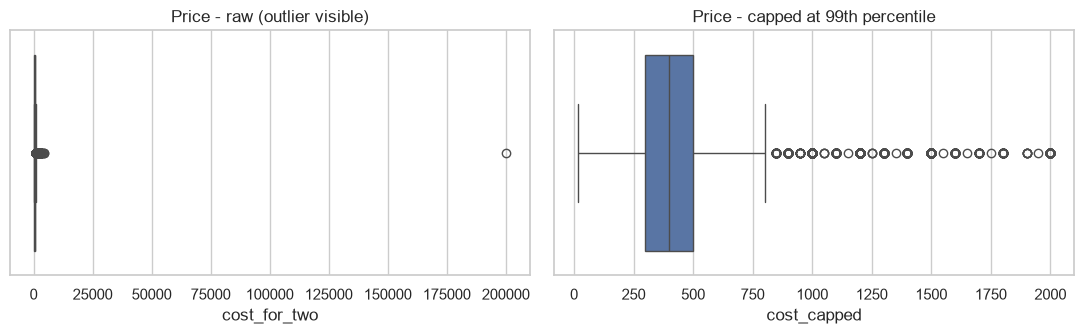

In [26]:
df = c.clean_cost(df)
print("Missing prices imputed:", int(df["cost_missing"].sum()))
print("Raw max:", df["cost_for_two"].max(), "| capped max:", df["cost_capped"].max())

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
sns.boxplot(x=df["cost_for_two"], ax=ax[0]); ax[0].set_title("Price - raw (outlier visible)")
sns.boxplot(x=df["cost_capped"], ax=ax[1]); ax[1].set_title("Price - capped at 99th percentile")
plt.tight_layout(); plt.show()

### 3.5 Review star percentages
`"79%"` becomes `79.0`. Restaurants with no reviews get NaN (not fake zeros). We also add three helper features: `positive_pct` (4 + 5 stars), `extreme_pct` (5 + 1 stars) and `polarization_pct` (high only when both 5-star and 1-star shares are large, meaning people love it or hate it).

> These columns are what the rating is *built from*. Use them for analysis only, never as inputs when predicting the rating (data leakage).

In [27]:
df = c.clean_star_percentages(df)
df[["name", "rating", "star5_pct", "star1_pct", "positive_pct", "polarization_pct"]].head()

,name,rating,star5_pct,star1_pct,positive_pct,polarization_pct
0,AB's - Absolute Barbecues,4.9,79.0,3.0,92.0,6.0
1,Cafe Co2 Resto Lounge,4.6,61.0,9.0,81.0,18.0
2,Paasha - JW Marriott Pune,4.6,62.0,4.0,88.0,8.0
3,I Amsterdam,4.3,45.0,7.0,79.0,14.0
4,FC Road Social,4.5,63.0,8.0,83.0,16.0


### 3.6 Cuisines, restaurant type, amenities, payments
Cuisines and amenities are stored as `|`-separated text (easy to load into MongoDB later). We also create counts and the primary cuisine/type for modelling.

In [28]:
df = c.parse_list_columns(df, amenity_cols)
df = c.add_payment_flags(df)
df, amenity_cols, dropped = c.drop_constant_amenities(df, amenity_cols)
df = df.drop(columns=["phone"])

print("Constant amenity columns dropped:", dropped)
print("Amenity columns kept:", len(amenity_cols))
df[["name", "cuisines", "n_cuisines", "primary_cuisine", "primary_type", "n_amenities"]].head()

Constant amenity columns dropped: []
Amenity columns kept: 86


,name,cuisines,n_cuisines,primary_cuisine,primary_type,n_amenities
0,AB's - Absolute Barbecues,Continental|North Indian|Chinese,3,Continental,Casual Dining,6
1,Cafe Co2 Resto Lounge,North Indian|Chinese|Continental|Kebab|Seafood,5,North Indian,Lounge,13
2,Paasha - JW Marriott Pune,North Indian|Kebab|Biryani,3,North Indian,Fine Dining,9
3,I Amsterdam,Asian|European|Modern Indian|Italian,4,Asian,Casual Dining,9
4,FC Road Social,North Indian|Chinese|Biryani|American|Continental,5,North Indian,Bar,7


## 4. Validation after cleaning

In [29]:
assert df["url"].duplicated().sum() == 0
assert (df["rating"].dropna() > 0).all()
assert df["votes"].dtype.kind == "i"

print("Final shape:", df.shape)
na = df.isna().sum()
na[na > 0]

Final shape: (12134, 116)


rating              4465
cost_for_two        2108
star5_pct           4486
star4_pct           4486
star3_pct           4486
star2_pct           4486
star1_pct           4486
positive_pct        4486
extreme_pct         4486
polarization_pct    4486
dtype: int64

In [30]:
# Lab 1 style summary statistics
stats = df[["rating", "votes", "cost_capped"]].agg(["count", "mean", "median", "std", "var", "min", "max"]).T
stats.round(2)

,count,mean,median,std,var,min,max
rating,7669.0,3.44,3.4,0.42,0.17,2.0,4.9
votes,12134.0,93.76,9.0,327.10,106992.38,0.0,7029.0
cost_capped,12134.0,460.96,400.0,317.14,100576.37,15.0,2000.0


## 5. Quick visual check

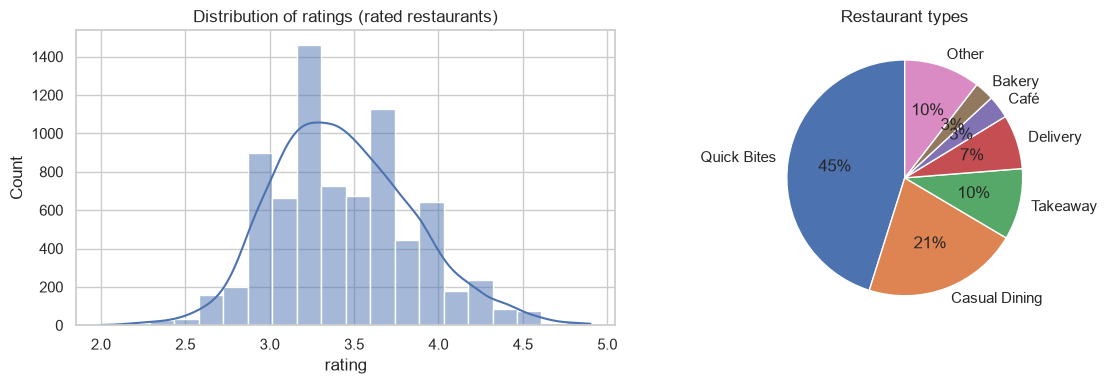

In [31]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df["rating"].dropna(), bins=20, kde=True, ax=ax[0])
ax[0].set_title("Distribution of ratings (rated restaurants)")

top = df["primary_type"].value_counts()
pie = pd.concat([top.head(6), pd.Series({"Other": top.iloc[6:].sum()})])
ax[1].pie(pie, labels=pie.index, autopct="%1.0f%%", startangle=90)
ax[1].set_title("Restaurant types")

plt.tight_layout(); plt.show()

In [32]:
r = df["rating"].dropna()
print(f"Rated restaurants: {len(r)}  |  rating >= 4.0: {(r >= 4).mean():.1%}  |  skew: {r.skew():.2f}")

Rated restaurants: 7669  |  rating >= 4.0: 11.2%  |  skew: 0.34


**Observation:** ratings cluster around 3.4 and only about 1 in 9 rated restaurants reaches 4.0 or above. Our later classification target (`rating >= 4.0`) is therefore **imbalanced**, so we will use F1 and ROC-AUC, not accuracy alone.

## 6. Save the cleaned dataset

In [33]:
os.makedirs("../data/processed", exist_ok=True)
OUT = "../data/processed/restaurants_clean.csv"
df.to_csv(OUT, index=False)
print("Saved:", OUT, df.shape)

Saved: ../data/processed/restaurants_clean.csv (12134, 116)


## 7. Notes for the report (fill in)

- Rows removed as duplicates: ____
- Unrated restaurants (kept for EDA, excluded from rating models): ____
- Price imputation method and number imputed: ____
- Price outlier handling: ____
- Biggest finding in this step: ____